<a href="https://colab.research.google.com/github/AI4ChemS/CHE1147/blob/main/tutorials/tutorial_09_bayesian_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Optimization

In this tutorial, we will build an end-to-end bayesian optimization loop to find high performing MOFs. Bayesian optimization begins with an initial set of labelled data. In this tutorial, we are using simulated CO2 uptakes, but imagine if we were using experimentally tested CO2 uptakes instead. The relative cost and effort to conduct an experiment like this is high - for every MOF in our initial data pool, we have to synthesize it and test its CO2 uptake. This is why bayesian optimization exists, to find high performing materials with as few data points (experiments) as possible.

### The Bayesian Optimization Loop

![BayesOPT](https://github.com/AI4ChemS/CHE1147/blob/main/assets/BO_pipeline.png)

Bayesian Optimization (BO) is used to optimize an expensive black-box function — usually a physical experiment or simulation — where each evaluation is costly. The core idea is to build a probabilistic model of the objective function and use it to choose the most informative next experiment.
0) Define the Objective Function
Before starting, clearly define:
the function you want to optimize (e.g., a material property)
the domain of inputs
whether evaluations are expensive, noisy, or constrained
This is the black-box function BO tries to learn efficiently.
1) Create an Initial Dataset
Select an initial design, typically using random sampling, Latin hypercube, or Sobol sequences.
This gives you a small set of input–output pairs to start modeling the function.
2) Train a Surrogate Model
Fit a surrogate model to the current dataset.
Gaussian Processes (GPs) are the classic choice because they provide:
a predicted mean (model belief about the function value)
a predicted variance (model uncertainty)
Other models (random forests, Bayesian neural nets, TPE) can also be used.
3) Use an Acquisition Function to Select the Next Point
The acquisition function determines where to evaluate next. It uses both:
exploitation (sample where predicted values are high)
exploration (sample where uncertainty is large)
Common acquisition functions:
Expected Improvement (EI)
Upper Confidence Bound (UCB)
Probability of Improvement (PI)
Thompson sampling
Its two goals are:
Find regions likely to contain high-performing candidates
Improve the surrogate model by sampling uncertain areas
This is the exploration–exploitation trade-off.
4) Run the Experiment / Evaluate the Objective
Conduct the actual experiment or simulation to obtain the true function value at the selected point.
5) Update the Dataset and Retrain the Surrogate
Add the new data point to your pool and refit the surrogate model.
As more points are added, the model becomes increasingly accurate.
6) Iterate Until a Termination Condition Is Met
You loop steps 3–5 until:
you reach a budget limit
improvements fall below a threshold
the acquisition function value is very small
you’ve achieved a target property value


# 0. Setup programming environment

### 0.1 Installing packages

If you are running this notebook locally after cloning [UofT-CHE1147](https://github.com/AI4ChemS/CHE1147) repo, simply install the conda environment

```python
conda env create -f environment.yml
conda activate che1147
```

## Uncomment the Cell Below if you are using Google Collab

In [ ]:
# import os, sys, urllib.request

# !pip install -r https://github.com/AI4ChemS/CHE1147/raw/refs/heads/main/requirements_colab.txt

# CHE1147_DIR = "/content/che1147_files"
# os.makedirs(CHE1147_DIR, exist_ok=True)
# data_URL = "https://github.com/AI4ChemS/CHE1147/raw/refs/heads/main/data/MOF_CoRE2019.csv"
# descriptors_URL = "https://github.com/AI4ChemS/CHE1147/raw/refs/heads/main/tutorials/MOF_descriptors.py"

# local_descriptor_path = os.path.join(CHE1147_DIR, "MOF_descriptors.py")
# urllib.request.urlretrieve(descriptors_URL, local_descriptor_path)

# local_data_path = os.path.join(CHE1147_DIR, "MOF_CoRE2019.csv")
# urllib.request.urlretrieve(data_URL, os.path.join(CHE1147_DIR, "MOF_CoRE2019.csv"))

# if CHE1147_DIR not in sys.path:
#     sys.path.append(CHE1147_DIR)


## 2) Load Libraries

In this section we import the libraries used throughout the tutorial.  
These cover **data handling**, **Bayesian optimization with BoTorch**, **evaluation metrics**, **plotting**, and a few **utility** helpers.

> ✅ You already installed `botorch` in Part 1 (Colab check). The rest are common scientific Python packages.

### What this cell sets up
- **Core stack**: `pandas`, `numpy`, `torch`
- **Bayesian Optimization** (BoTorch & GPyTorch):
  - `SingleTaskGP` (Gaussian Process model)
  - `ExactMarginalLogLikelihood` and `fit_gpytorch_mll` (training the GP)
  - `ExpectedImprovement` (acquisition function we’ll optimize)
- **Evaluation metrics**: MAE, MSE, \(R^2\), and **Spearman** correlation
- **Plotting**: `matplotlib.pyplot` for visualizing iterations and results
- **Preprocessing**: `StandardScaler` for feature/target scaling
- **Notebook utilities**: `clear_output`, `display` for smooth updates in Colab/Jupyter
- **General utilities**: `warnings`, `random`, `time`, `os`, `argparse`, `csv`, `pickle`, `sys`

> ℹ️ Tip: If you run this in **Google Colab**, plots that update in a loop work best using `clear_output`/`display` (we’ll use these later).



In [ ]:
import pandas as pd
import numpy as np
import torch
from botorch.models import SingleTaskGP
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll
from scipy.stats import norm
from botorch.acquisition.analytic import ExpectedImprovement
import matplotlib.pyplot as plt
import warnings
import random
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr
import time
import os
import argparse
import csv
import pickle
import sys
from sklearn.preprocessing import StandardScaler
from IPython.display import clear_output, display


## 0.2 Load Data

In [ ]:
# load data locally

running_in_colab = 'google.colab' in str(get_ipython())

if running_in_colab:
    DATA_DIR = "/content/che1147_files"
    DATA_FILE = os.path.join(DATA_DIR, "MOF_CoRE2019.csv")
else:
    DATA_DIR = "../data"
    DATA_FILE = os.path.join(DATA_DIR, "MOF_CoRE2019.csv")

try:
    df = pd.read_csv(DATA_FILE)
    print(f"✅ Loaded data from {DATA_FILE}, shape = {df.shape}")

except FileNotFoundError:
    # Fallback: try to load from GitHub raw URL
    url = "https://github.com/AI4ChemS/CHE1147/raw/refs/heads/main/data/MOF_CoRE2019.csv"
    try:
        df = pd.read_csv(url)
        print(f"🌐 Loaded data from GitHub, shape = {df.shape}")
    except Exception as e:
        print(f"❌ Could not find {DATA_FILE} locally or on GitHub.")
        raise e

## 3) Scaling the Data

Before training our models, we often need to **scale the features** so that they are comparable in magnitude.  
This helps optimization algorithms converge faster and avoids situations where one feature dominates others due to its scale.

The function below, `scale_dataframe`, provides two common options for scaling:

- **Standardization** (default):  
  Transforms each column to have **zero mean** and **unit variance** using `StandardScaler`.  
  This is useful when features follow approximately Gaussian distributions.

- **Normalization**:  
  Rescales each column to the range \([0, 1]\).  
  This is useful when features have different units or ranges and you want them on the same scale.

If neither option is selected, the function raises an error.

### Function: `scale_dataframe`
- **Inputs**:
  - `df` (`pd.DataFrame`): input data
  - `mode` (`str`): either `"standardize"` (default) or `"normalize"`
- **Output**:
  - Returns a new `pd.DataFrame` with scaled values, preserving original column names and row indices.


In [ ]:
def scale_dataframe(df: pd.DataFrame, mode: str = "standardize") -> pd.DataFrame:
    X = df.values

    if mode == "standardize":
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    elif mode == "normalize":
        for i in range(X.shape[1]):
            col_min = np.min(X[:, i])
            col_max = np.max(X[:, i])
            if col_max - col_min != 0:
                X[:, i] = (X[:, i] - col_min) / (col_max - col_min)
            else:
                X[:, i] = 0.0

    else:
        raise ValueError("mode must be 'standardize' or 'normalize'")
    return pd.DataFrame(X, columns=df.columns, index=df.index)


## 4) End-to-End Bayesian Optimization Loop: `bo_run`

This function runs a full **Bayesian Optimization (BO)** loop over an unlabelled pool, starting with a random initialization and iteratively acquiring new samples according to a chosen **acquisition function**.

At a high level:

1. **Load & prep data** (labelled target lives in `labelled_data_dir`, features in `unlabelled_data_dir`).
2. **Randomly initialize** a set of acquired indices and reveal their labels.
3. **Standardize features** (via `scale_dataframe`) and build tensors for BoTorch.
4. **Fit a GP model** to the *currently acquired* data.
5. **Score all candidates** with the acquisition function (EI / max mean / max variance).
6. **Pick the best new point** not yet acquired; reveal its label; update the plot.
7.  **Evaluate the candidate**: run the *time-consuming test* (e.g. simulation, SDL pipeline, or lab experiment) to obtain the true label of the suggested candidate.  
    - In this tutorial, we **simulate** the evaluation by simply looking up the value from the labelled dataset (`df_labelled`).  
    - In a real workflow, this is where your **expensive evaluation** would happen before feeding the result back into the BO loop.
8. **Repeat** until `nb_iterations` is reached.


In [ ]:
def bo_run(
    df_full,
    feature_cols,
    nb_iterations,
    nb_initialization,
    which_acquisition,
    store_explore_exploit_terms=True,
    seed_number=42,
    noise_ratio=0,
    label=None,
):
    assert nb_iterations >= nb_initialization
    assert which_acquisition in ["max y_hat", "EI", "max sigma"]
    assert label is not None, "You must pass the target column name as `label`."

    # 1. Load & prep data
    df_labelled = df_full.copy()  # this is the oracle / fully labelled dataset

    if "MOFname" in df_labelled.columns:
        df_labelled = df_labelled.drop(columns=["MOFname"])

    # Clean BEFORE constructing df
    df_labelled = (
        df_labelled
        .dropna(subset=feature_cols + [label])     # drop rows missing any feature or target
        .drop_duplicates(subset=feature_cols)      # drop duplicate feature rows
        .reset_index(drop=True)
    )

    # Start from an "unlabelled" view: hide the target, then reveal as BO acquires points
    df = df_labelled.copy()
    df[label] = np.nan

    # make sure requested features exist
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Requested feature columns not in df: {missing}")

    # 2. Randomly initialize
    np.random.seed(seed_number)  # was hard-coded 42; now uses the argument
    ids_acquired = np.random.choice(
        np.arange(df.shape[0]), size=nb_initialization, replace=False
    )

    # 3. Standardize features
    # reveal labels for the initially acquired points
    df.loc[ids_acquired, label] = df_labelled.loc[ids_acquired, label].values

    # use ONLY the chosen feature columns (instead of df.drop(columns=[label]))
    df_X = df[feature_cols].astype("float64")
    df_X = scale_dataframe(df_X, mode="standardize")
    df_y = df[label]  # Series with NaNs for unacquired points

    if which_acquisition == "EI" and store_explore_exploit_terms:
        explore_exploit_balance = np.array(
            [(np.nan, np.nan) for _ in range(nb_iterations)]
        )
    else:
        explore_exploit_balance = []

    fig, ax = plt.subplots()

    for i in range(nb_initialization, nb_iterations):
        print("iteration:", i, end="\r")

        X = torch.from_numpy(np.array(df_X))
        y = torch.from_numpy(np.array(df_y))
        y = y.unsqueeze(1)
        X_unsqueezed = X.unsqueeze(1)

        noisy_exp = True
        if noisy_exp:
            noise_std = noise_ratio * y
            yvar = noise_std**2

        y_acquired = y[ids_acquired]
        X_acquired = X[ids_acquired]
        yvar_acquired = yvar[ids_acquired]
        y_acquired = (y_acquired - torch.mean(y_acquired)) / torch.std(y_acquired)

        # 4. Fit a GP model
        model = SingleTaskGP(X_acquired, y_acquired, train_Yvar=yvar_acquired)
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)

        # 5. Set up acquisition function and score all candidates
        if which_acquisition == "EI":
            acquisition_function = ExpectedImprovement(
                model, best_f=y_acquired.max().item()
            )
            acquisition_values = acquisition_function.forward(X_unsqueezed)
        elif which_acquisition == "max y_hat":
            with torch.no_grad():
                acquisition_values = model.posterior(X_unsqueezed).mean.squeeze()
        elif which_acquisition == "max sigma":
            with torch.no_grad():
                acquisition_values = model.posterior(X_unsqueezed).variance.squeeze()
        else:
            raise Exception("not a valid acquisition function")

        # 6. Pick the best new point
        ids_sorted_by_aquisition = acquisition_values.argsort(descending=True)
        for id_max_aquisition_all in ids_sorted_by_aquisition:
            if id_max_aquisition_all.item() not in ids_acquired:
                id_max_aquisition = id_max_aquisition_all.item()
                break

        # if EI, compute and store explore-exploit terms that contribute to EI separately.
        if which_acquisition == "EI" and store_explore_exploit_terms:
            y_pred = (
                model.posterior(X_unsqueezed[id_max_aquisition])
                .mean.squeeze()
                .detach()
                .numpy()
            )
            sigma_pred = np.sqrt(
                model.posterior(X_unsqueezed[id_max_aquisition])
                .variance.squeeze()
                .detach()
                .numpy()
            )
            y_max = y_acquired.max().item()
            z = (y_pred - y_max) / sigma_pred
            explore_term = sigma_pred * norm.pdf(z)
            exploit_term = (y_pred - y_max) * norm.cdf(z)
            # we drop the strict np.isclose() assert to avoid numerical AssertionError
            explore_exploit_balance[i] = (explore_term, exploit_term)

        ####################################################################
        # 7. Evaluate the candidate (reveal its true label)
        sample_to_run = X[id_max_aquisition]
        df_y.loc[id_max_aquisition] = df_labelled.loc[id_max_aquisition, label]
        ids_acquired = np.concatenate((ids_acquired, [id_max_aquisition]))
        ####################################################################

        ax.clear()
        ax.plot(df_y.loc[ids_acquired].values, marker="o")
        ax.axhline(
            y=df_labelled[label].max(), linestyle="--", color="gray"
        )
        ax.axhline(
            y=np.sort(df_labelled[label])[-100],
            linestyle="--",
            color="blue",
            label="100th highest",
        )

        ax.fill_between(
            x=range(len(df_y.loc[ids_acquired])),
            y1=np.sort(df_labelled[label])[-100],
            y2=df_labelled[label].max(),
            color="blue",
            alpha=0.1,
        )
        ax.set_title(f"Iteration {i}")
        ax.set_xlabel("Index")
        ax.set_ylabel(label)

        fig.canvas.draw()
        clear_output(wait=True)
        display(fig)
        time.sleep(0.5)

        y = torch.from_numpy(np.array(df_y))
        y = y.unsqueeze(1)
        y_acquired = y[ids_acquired]
        y_acquired = (y_acquired - torch.mean(y_acquired)) / torch.std(y_acquired)

    plt.ioff()
    plt.show()

    # 8. Repeat
    return df_X, df_y, ids_acquired, explore_exploit_balance


## 5) Mathematical Formulation

We want to find the MOF with **maximum CO₂ uptake**:

$$
x^\star = \arg\max_{x \in X} f(x),
$$

where:
- $X = \{x_1, \dots, x_N\}$ are MOF candidates (features = Z++ or RACs),
- $f(x)$ is the true uptake (measured by experiment/simulation, here read from dataset).

---

**Bayesian Optimization loop**

- GP surrogate gives posterior mean $\mu_t(x)$ and variance $\sigma_t^2(x)$.
- Next point is chosen by maximizing an acquisition function:

$$
x_{t+1} = \arg\max_{x \in X \setminus A_t} a_t(x).
$$

Choices:
- **Expected Improvement (EI)**:  
  $$
  \operatorname{EI}(x) = (\mu_t(x)-f_t^{\max}) \, \Phi(z) + \sigma_t(x)\,\phi(z), \quad
  z = \frac{\mu_t(x)-f_t^{\max}}{\sigma_t(x)}
  $$
- **Max mean**: $a_t(x)=\mu_t(x)$  
- **Max variance**: $a_t(x)=\sigma_t^2(x)$  

---

💡 Each step: BO suggests a candidate → you **evaluate** it (simulation/labwork/etc.) → feed the result back into the loop.


In [ ]:
label = 'CO2 uptake at 16 bar and 298K'

# Just work directly from df
y = df[label].dropna().values

plt.figure()
plt.hist(y, bins=40)
plt.title(f"Distribution of {label}")
plt.xlabel(label)
plt.ylabel("Count")
plt.show()


## 6) Run the Experiment (CoRE2019, CO₂ Uptake @ High Pressure)

In this section we execute the full Bayesian Optimization loop using `bo_run`.

**Study context**
- **Dataset**: CoRE2019 MOF database.
- **Targets (label)**: High-pressure **CO₂ uptake** (here: `pure_uptake_CO2_298.00_1600000`).
- **Features in two attempts**:
  1. **Geometric features** computed with **Z++** (use the Z++-based CSVs).
  2. **Chemical descriptors** computed with **RACs** (use the RACs-based CSVs).
  

### Configuration
- `nb_iterations=200` total BO steps (including the initial random acquisitions).
- `nb_initialization=10` random points to seed the GP.
- Acquisition function: `"EI"` (Expected Improvement).

> **Outputs saved**
> - The combined features+labels DataFrame is written to `df.csv` at the end of the run.
> - `ids_acquired` and (optionally) `explore_exploit_balance` are stored in `bo_res` for inspection.
> - The live plot in the previous step updates during the run; set up your notebook for continuous display (already handled in `bo_run`).




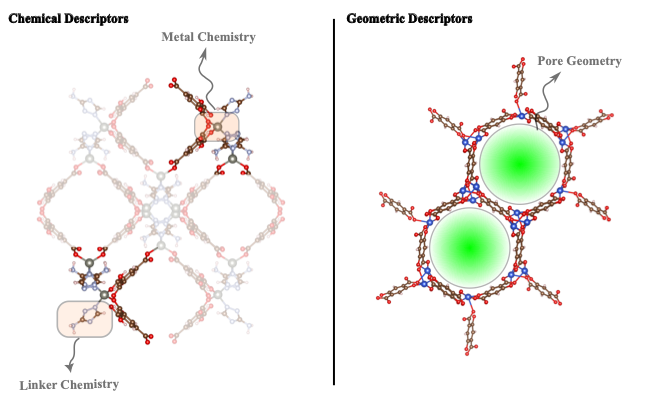

## 6.1 BO Using Only Geometric Features

In [ ]:
from MOF_descriptors import geometric_descriptors

TARGET = "CO2 uptake at 16 bar and 298K"
FEATURES = geometric_descriptors

nb_iterations = 200
nb_initialization = 10
which_acquisition = "EI"
seed_number = 42

print("# Mixtures in initialization:", nb_initialization)
print("Using", len(FEATURES), "geometric descriptors.")

bo_res = {"ids_acquired": [], "explore_exploit_balance": []}

print("\nRUN Started")
t0 = time.time()

df_X, df_y, ids_acquired, explore_exploit_balance = bo_run(
    df_full=df,               # your existing dataframe
    feature_cols=FEATURES,    # only geometric descriptors
    nb_iterations=nb_iterations,
    nb_initialization=nb_initialization,
    which_acquisition=which_acquisition,
    store_explore_exploit_terms=True,
    seed_number=seed_number,
    noise_ratio=0.05,
    label=TARGET,
)

bo_res["ids_acquired"].append(ids_acquired)
bo_res["explore_exploit_balance"].append(explore_exploit_balance)

print("took time t = ", (time.time() - t0) / 60, "min\n")

df_out = pd.concat([df_X, df_y], axis=1)
df_out.to_csv("df_geom_only.csv", index=True)


 $\color{Aqua}{\textsf{Short question}}$
- Are we trying to select new data points to improve our surrogate function? Or just select points with the potential for high CO2 uptakes?

<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li>Both! We want to improve our surrogate function while simultaneously trying to select promising data points. This is the tradeoff between exploration and exploitation - you don't want to waste an entire experiment on a material you know is likely to not be promising, but you also want to explore new regions of feature space that your model currently might not be understanding well
</ul>
</details>

## 6.1 BO Using Only RACs

In [ ]:
from MOF_descriptors import linker_descriptors, metalcenter_descriptors, functionalgroup_descriptors, summed_linker_descriptors, summed_metalcenter_descriptors, summed_functionalgroup_descriptors

TARGET = "CO2 uptake at 16 bar and 298K"
FEATURES = (
    summed_functionalgroup_descriptors
    + summed_linker_descriptors
    + summed_metalcenter_descriptors
)

nb_iterations = 200
nb_initialization = 10
which_acquisition = "EI"
seed_number = 42

print("# Mixtures in initialization:", nb_initialization)
print("Using", len(FEATURES), "geometric descriptors.")

bo_res = {"ids_acquired": [], "explore_exploit_balance": []}

print("\nRUN Started")
t0 = time.time()

df_X, df_y, ids_acquired, explore_exploit_balance = bo_run(
    df_full=df,               # your existing dataframe
    feature_cols=FEATURES,    # only geometric descriptors
    nb_iterations=nb_iterations,
    nb_initialization=nb_initialization,
    which_acquisition=which_acquisition,
    store_explore_exploit_terms=True,
    seed_number=seed_number,
    noise_ratio=0.05,
    label=TARGET,
)

bo_res["ids_acquired"].append(ids_acquired)
bo_res["explore_exploit_balance"].append(explore_exploit_balance)

print("took time t = ", (time.time() - t0) / 60, "min\n")

df_out = pd.concat([df_X, df_y], axis=1)
df_out.to_csv("df_geom_only.csv", index=True)


## 6.1 BO Using All Features

In [ ]:
from MOF_descriptors import geometric_descriptors, linker_descriptors, metalcenter_descriptors, functionalgroup_descriptors, summed_linker_descriptors, summed_metalcenter_descriptors, summed_functionalgroup_descriptors

TARGET = "CO2 uptake at 16 bar and 298K"
FEATURES = (
    geometric_descriptors
    + summed_functionalgroup_descriptors
    + summed_linker_descriptors
    + summed_metalcenter_descriptors
)

nb_iterations = 200
nb_initialization = 10
which_acquisition = "EI"
seed_number = 42

print("# Mixtures in initialization:", nb_initialization)
print("Using", len(FEATURES), "geometric descriptors.")

bo_res = {"ids_acquired": [], "explore_exploit_balance": []}

print("\nRUN Started")
t0 = time.time()

df_X, df_y, ids_acquired, explore_exploit_balance = bo_run(
    df_full=df,               # your existing dataframe
    feature_cols=FEATURES,    # only geometric descriptors
    nb_iterations=nb_iterations,
    nb_initialization=nb_initialization,
    which_acquisition=which_acquisition,
    store_explore_exploit_terms=True,
    seed_number=seed_number,
    noise_ratio=0.05,
    label=TARGET,
)

bo_res["ids_acquired"].append(ids_acquired)
bo_res["explore_exploit_balance"].append(explore_exploit_balance)

print("took time t = ", (time.time() - t0) / 60, "min\n")

df_out = pd.concat([df_X, df_y], axis=1)
df_out.to_csv("df_geom_only.csv", index=True)
